In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Read the data
X_full = pd.read_csv('../external-data/train.csv', index_col='Id')
X_test_full = pd.read_csv('../external-data/test.csv', index_col='Id')

# Remove rows with missing target, separate target from predictors
X_full.dropna(axis=0, subset=['SalePrice'], inplace=True)
y = X_full.SalePrice
X_full.drop(['SalePrice'], axis=1, inplace=True)

# drop outliers areas
outlier_idx = X_full[(X_full['GrLivArea'] > 4000) & (y < 300000)].index
X_full = X_full.drop(outlier_idx)
y = y.drop(outlier_idx)

for df in (X_full, X_test_full):
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath']
                        + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

# reverted: log-transform made dollar-MAE worse, since criterion='absolute_error' then optimizes
# absolute error in log-space (~percentage error) instead of the dollar-MAE we actually score on
# y = np.log1p(y)  # log-transform target: SalePrice is right-skewed
y = y  # back to raw-dollar SalePrice, matching criterion='absolute_error'

# Break off validation set from training data (80/20 split on 1460 rows)
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X_full, y, 
                                                                train_size=0.8, test_size=0.2,
                                                                random_state=0)


# Select categorical columns with relatively low cardinality (convenient but arbitrary)
# categorical_cols = [cname for cname in X_train_full.columns if
#                     X_train_full[cname].nunique() < 10 and 
#                     X_train_full[cname].dtype == "object"]

# No dropping
categorical_cols = [cname for cname in X_train_full.columns if
                    X_train_full[cname].dtype == "object"]

print(categorical_cols)

# Select numerical columns
numerical_cols = [cname for cname in X_train_full.columns if 
                X_train_full[cname].dtype in ['int64', 'float64']]


# Columns that just should have 'None' in spite of NaN
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for df in (X_train_full, X_valid_full, X_test_full):
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')

# Keep selected columns only
my_cols = categorical_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()
X_test = X_test_full[my_cols].copy()

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [2]:
X_train.head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,TotalSF,HouseAge,TotalBath
Id,,,,,,,,,,,,,,,,,,,,,
1172,RL,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,0,0,288,0,1400,11,2008,2522,50,2.0
76,RM,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,...,0,0,0,0,0,11,2009,1450,36,2.0
391,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,...,112,0,0,0,0,4,2008,2228,108,2.0
1284,RL,Pave,None,Reg,Low,AllPub,Corner,Gtl,Mitchel,Norm,...,0,0,0,0,0,4,2010,2736,39,3.0
684,RL,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,CollgCr,Norm,...,0,0,0,0,0,7,2007,3294,5,3.0


In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor

# Preprocessing for numerical data
# numerical_transformer = SimpleImputer(strategy='constant')
# numerical_transformer = SimpleImputer(strategy='median')
numerical_transformer = SimpleImputer()

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Define model
# model = RandomForestRegressor(n_estimators=100, criterion='absolute_error', random_state=0)

# Preprocessing of training data, fit model 
# clf.fit(X_train, y_train)

# reverted: y is back to raw dollars, so predictions come out in dollars directly - no expm1 needed
# preds_log = clf.predict(X_valid)          # log-transform version
# preds = np.expm1(preds_log)
# y_valid_dollars = np.expm1(y_valid)
# print('MAE:', mean_absolute_error(y_valid_dollars, preds))

# preds = clf.predict(X_valid)
# print('MAE:', mean_absolute_error(y_valid, preds))

In [4]:
# apply cross-validation
from sklearn.model_selection import cross_val_score

def get_score(n_estimators):
    model = RandomForestRegressor(n_estimators, criterion='absolute_error',
                               max_depth=None, min_samples_leaf=1,
                               max_features='sqrt', random_state=0)

    # Bundle preprocessing and modeling code in a pipeline
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                        ('model', model)
                        ])

    scores = -1 * cross_val_score(clf, X_full, y,
                                  cv=5,
                                  scoring='neg_mean_absolute_error')
    return scores.mean()

In [5]:
results = {}
for i in range(1,9):
    results[50*i] = get_score(50*i)

print(results)

{50: np.float64(17389.076301511086), 100: np.float64(16978.992673974957), 150: np.float64(16729.729668941927), 200: np.float64(16615.816811220167), 250: np.float64(16554.613647159065), 300: np.float64(16552.170526679376), 350: np.float64(16554.859904210465), 400: np.float64(16545.9552975539)}


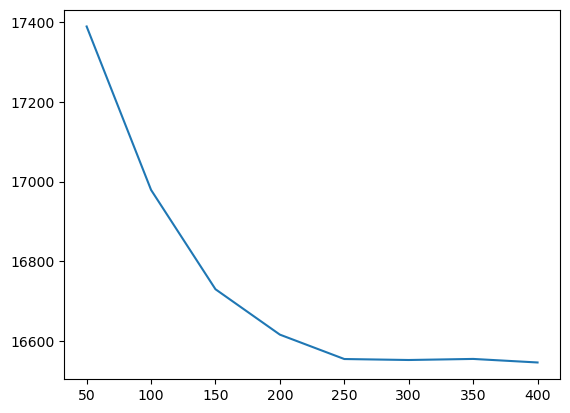

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(list(results.keys()), list(results.values()))
plt.show()



In [ ]:
from sklearn.metrics import mean_absolute_error
# Pick the n_estimators with the lowest cross-validated MAE from the sweep above
n_estimators_best = 400

model = RandomForestRegressor(n_estimators_best, criterion='absolute_error',
                               max_depth=None, min_samples_leaf=1,
                               max_features='sqrt', random_state=0)

clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('model', model)])

clf.fit(X_train, y_train)


# prediction on validation set
val_pred = clf.predict(X_valid)

print("MAE: ", mean_absolute_error(y_valid, val_pred))

TypeError: can only concatenate str (not "float") to str

In [ ]:
preds_test = clf.predict(X_test)

In [ ]:
output = pd.DataFrame({'Id': X_test.index,
                       'SalePrice': preds_test})
output.to_csv('submission-pipeline-cval.csv', index=False)